# Private Credit Underwriting & Borrower Risk Assessment Platform

**Borrower:** PepsiCo, Inc. (PEP)  
**Purpose:** Illustrative private-credit underwriting framework using historical financial statements, leverage, debt service, cash-flow analysis, scenario stress testing, and hypothetical debt-capacity analysis.

> **Important:** This is an educational/portfolio model, not a credit rating, investment recommendation, or statement of PepsiCo's actual lending covenants. All facility terms and covenant thresholds in this notebook are hypothetical.

### Underwriting workflow
**Financial statements → normalization → credit metrics → risk score → stress scenarios → debt capacity → covenant headroom → credit committee summary**


## Portfolio-Ready Executed Version

**Status:** Executed successfully in Google Colab with outputs retained.  
**Purpose:** Portfolio demonstration of a finance-first private-credit underwriting workflow.  

> The model is intentionally illustrative. Facility terms, leverage/coverage thresholds and the internal risk score are analytical assumptions rather than contractual terms, an external rating, or a lending recommendation.


## 1. Environment Setup

In [ ]:
!pip -q install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Borrower & Underwriting Assumptions

The assumptions below are deliberately visible rather than hidden inside the code. This makes the model easier to audit and defend in an interview.


In [ ]:
TICKER = "PEP"

# Hypothetical underwriting policy thresholds
MAX_NET_DEBT_EBITDA = 4.0
MIN_INTEREST_COVERAGE = 3.0

# Illustrative new facility
PROPOSED_DEBT = 2_000_000_000       # $2.0bn
PROPOSED_RATE = 0.08                # 8.0%

# Forward stress assumptions
BASE_REVENUE_CHANGE = 0.05
DOWNSIDE_REVENUE_CHANGE = -0.05
SEVERE_REVENUE_CHANGE = -0.15

DOWNSIDE_MARGIN_SHOCK = -0.03       # -300 bps
SEVERE_MARGIN_SHOCK = -0.06         # -600 bps

DOWNSIDE_INTEREST_SHOCK = 0.15
SEVERE_INTEREST_SHOCK = 0.30

print(f"Borrower: {TICKER}")
print(f"Hypothetical leverage limit: {MAX_NET_DEBT_EBITDA:.1f}x")
print(f"Hypothetical minimum interest coverage: {MIN_INTEREST_COVERAGE:.1f}x")


Borrower: PEP
Hypothetical leverage limit: 4.0x
Hypothetical minimum interest coverage: 3.0x


## 3. Data Collection & Validation

Yahoo Finance is used here for reproducible programmatic retrieval. The model checks that all three statements are available before continuing.


In [ ]:
def fetch_financials(ticker_str: str):
    t = yf.Ticker(ticker_str)

    inc = t.financials
    bal = t.balance_sheet
    cf = t.cashflow

    if inc.empty or bal.empty or cf.empty:
        raise ValueError(f"Incomplete financial statements returned for {ticker_str}.")

    inc = inc.T.copy()
    bal = bal.T.copy()
    cf = cf.T.copy()

    for df in (inc, bal, cf):
        df.index = pd.to_datetime(df.index)
        df.sort_index(inplace=True)

    info = {}
    try:
        basic = t.info
        info = {
            "long_name": basic.get("longName", ticker_str),
            "market_cap": basic.get("marketCap", np.nan),
            "enterprise_value": basic.get("enterpriseValue", np.nan)
        }
    except Exception:
        info = {"long_name": ticker_str, "market_cap": np.nan, "enterprise_value": np.nan}

    return inc, bal, cf, info

df_inc, df_bal, df_cf, market_info = fetch_financials(TICKER)

print(f"Retrieved: {market_info['long_name']} ({TICKER})")
print("Income statement periods:", [d.strftime("%Y-%m-%d") for d in df_inc.index])


Retrieved: PepsiCo, Inc. (PEP)
Income statement periods: ['2021-12-31', '2022-12-31', '2023-12-31', '2024-12-31', '2025-12-31']


## 4. Financial Statement Normalization

Yahoo Finance field names can change. These helper functions search a list of possible labels and return the first available value. This makes the model less brittle.


In [ ]:
def get_value(df, date, candidates, default=np.nan):
    row = df.loc[date]
    for name in candidates:
        if name in row.index and pd.notna(row[name]):
            return float(row[name])
    return default

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b

common_dates = df_inc.index.intersection(df_bal.index).intersection(df_cf.index)
if len(common_dates) == 0:
    raise ValueError("No common reporting dates across the three statements.")

rows = []

for dt in common_dates:
    revenue = get_value(df_inc, dt, ["Total Revenue", "Operating Revenue"])
    ebit = get_value(df_inc, dt, ["EBIT", "Operating Income"])
    net_income = get_value(df_inc, dt, ["Net Income", "Net Income Common Stockholders"])

    da = get_value(df_cf, dt, [
        "Depreciation And Amortization",
        "Depreciation",
        "Depreciation Amortization Depletion"
    ], 0.0)
    da = 0.0 if pd.isna(da) else da

    ebitda = ebit + da if pd.notna(ebit) else np.nan

    current_debt = get_value(df_bal, dt, ["Current Debt", "Current Debt And Capital Lease Obligation"], 0.0)
    long_debt = get_value(df_bal, dt, ["Long Term Debt", "Long Term Debt And Capital Lease Obligation"], 0.0)
    current_debt = 0.0 if pd.isna(current_debt) else current_debt
    long_debt = 0.0 if pd.isna(long_debt) else long_debt
    total_debt = current_debt + long_debt

    cash = get_value(df_bal, dt, [
        "Cash And Cash Equivalents",
        "Cash Cash Equivalents And Short Term Investments"
    ], 0.0)
    cash = 0.0 if pd.isna(cash) else cash

    net_debt = total_debt - cash

    current_assets = get_value(df_bal, dt, ["Current Assets"])
    current_liabilities = get_value(df_bal, dt, ["Current Liabilities"])
    equity = get_value(df_bal, dt, ["Stockholders Equity", "Common Stock Equity"])

    cfo = get_value(df_cf, dt, ["Operating Cash Flow", "Total Cash From Operating Activities"])
    capex = get_value(df_cf, dt, ["Capital Expenditure", "Capital Expenditures"])
    capex = abs(capex) if pd.notna(capex) else 0.0
    fcf = cfo - capex if pd.notna(cfo) else np.nan

    interest = abs(get_value(df_inc, dt, [
        "Interest Expense",
        "Interest Expense Non Operating"
    ]))

    rows.append({
        "Date": dt,
        "Revenue": revenue,
        "EBIT": ebit,
        "EBITDA": ebitda,
        "Net Income": net_income,
        "Total Debt": total_debt,
        "Cash": cash,
        "Net Debt": net_debt,
        "Interest Expense": interest,
        "CFO": cfo,
        "Capex": capex,
        "FCF": fcf,
        "Current Assets": current_assets,
        "Current Liabilities": current_liabilities,
        "Equity": equity
    })

df_metrics = pd.DataFrame(rows).set_index("Date").sort_index()

df_metrics["Revenue Growth"] = df_metrics["Revenue"].pct_change()
df_metrics["EBITDA Margin"] = df_metrics.apply(lambda r: safe_ratio(r["EBITDA"], r["Revenue"]), axis=1)
df_metrics["EBIT Margin"] = df_metrics.apply(lambda r: safe_ratio(r["EBIT"], r["Revenue"]), axis=1)
df_metrics["Net Margin"] = df_metrics.apply(lambda r: safe_ratio(r["Net Income"], r["Revenue"]), axis=1)
df_metrics["Current Ratio"] = df_metrics.apply(lambda r: safe_ratio(r["Current Assets"], r["Current Liabilities"]), axis=1)
df_metrics["Working Capital"] = df_metrics["Current Assets"] - df_metrics["Current Liabilities"]
df_metrics["Debt / EBITDA"] = df_metrics.apply(lambda r: safe_ratio(r["Total Debt"], r["EBITDA"]), axis=1)
df_metrics["Net Debt / EBITDA"] = df_metrics.apply(lambda r: safe_ratio(r["Net Debt"], r["EBITDA"]), axis=1)
df_metrics["Debt / Equity"] = df_metrics.apply(lambda r: safe_ratio(r["Total Debt"], r["Equity"]), axis=1)
df_metrics["Interest Coverage"] = df_metrics.apply(lambda r: safe_ratio(r["EBITDA"], r["Interest Expense"]), axis=1)
df_metrics["FCF / Debt"] = df_metrics.apply(lambda r: safe_ratio(r["FCF"], r["Total Debt"]), axis=1)

display(df_metrics[[
    "Revenue","EBITDA","Net Debt","Interest Expense","FCF",
    "EBITDA Margin","Net Debt / EBITDA","Interest Coverage","FCF / Debt"
]].tail(5))


,Revenue,EBITDA,Net Debt,Interest Expense,FCF,EBITDA Margin,Net Debt / EBITDA,Interest Coverage,FCF / Debt
Date,,,,,,,,,
2021-12-31,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-31,"86,392,000,000.000","14,924,000,000.000","34,117,000,000.000","939,000,000.000","5,604,000,000.000",0.173,2.286,15.894,0.143
2023-12-31,"91,471,000,000.000","15,754,000,000.000","34,394,000,000.000","819,000,000.000","7,924,000,000.000",0.172,2.183,19.236,0.180
2024-12-31,"91,854,000,000.000","16,680,000,000.000","35,801,000,000.000","919,000,000.000","7,189,000,000.000",0.182,2.146,18.150,0.162
2025-12-31,"93,925,000,000.000","15,543,000,000.000","40,023,000,000.000","1,121,000,000.000","7,672,000,000.000",0.165,2.575,13.865,0.156


### Data-quality note

The latest complete period used for the headline credit profile is **FY2025**. Earlier periods with missing statement fields are retained in the historical dataset but are excluded from ratios where required inputs are unavailable. The programmatic Yahoo Finance data should be reconciled to primary company filings before any real underwriting use.


## 5. Historical Credit Profile

A lender generally focuses on earnings capacity, leverage, debt service, liquidity and cash generation rather than looking at a single ratio in isolation.


In [ ]:
latest = df_metrics.dropna(subset=["EBITDA","Net Debt","Interest Expense"]).iloc[-1]

print("LATEST HISTORICAL CREDIT PROFILE")
print("-" * 42)
print(f"Revenue:             ${latest['Revenue']/1e9:,.2f}bn")
print(f"EBITDA:              ${latest['EBITDA']/1e9:,.2f}bn")
print(f"Net Debt:            ${latest['Net Debt']/1e9:,.2f}bn")
print(f"Net Debt / EBITDA:   {latest['Net Debt / EBITDA']:.2f}x")
print(f"Interest Coverage:   {latest['Interest Coverage']:.2f}x")
print(f"FCF / Debt:          {latest['FCF / Debt']:.2%}")
print(f"EBITDA Margin:       {latest['EBITDA Margin']:.2%}")


LATEST HISTORICAL CREDIT PROFILE
------------------------------------------
Revenue:             $93.92bn
EBITDA:              $15.54bn
Net Debt:            $40.02bn
Net Debt / EBITDA:   2.57x
Interest Coverage:   13.87x
FCF / Debt:          15.60%
EBITDA Margin:       16.55%


## 6. Illustrative Borrower Risk Score

This is **not** a Moody's/S&P/Fitch rating. It is a transparent internal portfolio-model score using three credit dimensions:

- Leverage: 40%
- Interest coverage: 40%
- FCF / debt: 20%

Lower score = lower modeled risk. The weights and breakpoints are analyst assumptions and are explicitly disclosed.


In [ ]:
def risk_component_leverage(x):
    if x < 1.5: return 1
    if x < 3.0: return 2
    if x < 4.5: return 3
    if x < 6.0: return 4
    return 5

def risk_component_coverage(x):
    if x > 6.0: return 1
    if x > 4.0: return 2
    if x > 2.0: return 3
    if x > 1.5: return 4
    return 5

def risk_component_fcf(x):
    if x > 0.20: return 1
    if x > 0.10: return 2
    if x > 0.05: return 3
    if x > 0.00: return 4
    return 5

lev_score = risk_component_leverage(latest["Net Debt / EBITDA"])
cov_score = risk_component_coverage(latest["Interest Coverage"])
fcf_score = risk_component_fcf(latest["FCF / Debt"])

risk_score = round(0.40*lev_score + 0.40*cov_score + 0.20*fcf_score, 2)

print(f"Leverage component:        {lev_score}/5")
print(f"Interest coverage component:{cov_score}/5")
print(f"FCF/debt component:        {fcf_score}/5")
print(f"Illustrative risk score:   {risk_score}/5")
print("Lower score = lower modeled credit risk.")


Leverage component:        2/5
Interest coverage component:1/5
FCF/debt component:        2/5
Illustrative risk score:   1.6/5
Lower score = lower modeled credit risk.


## 7. Forward Stress Testing

The stress test asks: **what happens to debt-service capacity when operating performance deteriorates?**

For transparency, the scenarios change revenue, EBITDA margin and interest expense. The model then recalculates EBITDA and interest coverage.


In [ ]:
historical_margin = df_metrics["EBITDA Margin"].dropna().mean()
base = {
    "Revenue": latest["Revenue"] * (1 + BASE_REVENUE_CHANGE),
    "EBITDA": latest["Revenue"] * (1 + BASE_REVENUE_CHANGE) * historical_margin,
    "Interest Expense": latest["Interest Expense"],
}
down = {
    "Revenue": latest["Revenue"] * (1 + DOWNSIDE_REVENUE_CHANGE),
    "EBITDA": latest["Revenue"] * (1 + DOWNSIDE_REVENUE_CHANGE) * (historical_margin + DOWNSIDE_MARGIN_SHOCK),
    "Interest Expense": latest["Interest Expense"] * (1 + DOWNSIDE_INTEREST_SHOCK),
}
severe = {
    "Revenue": latest["Revenue"] * (1 + SEVERE_REVENUE_CHANGE),
    "EBITDA": latest["Revenue"] * (1 + SEVERE_REVENUE_CHANGE) * (historical_margin + SEVERE_MARGIN_SHOCK),
    "Interest Expense": latest["Interest Expense"] * (1 + SEVERE_INTEREST_SHOCK),
}

scenario_df = pd.DataFrame([base, down, severe], index=["Base Case","Downside","Severe Downside"])
scenario_df["Interest Coverage"] = scenario_df["EBITDA"] / scenario_df["Interest Expense"]
scenario_df["Net Debt / EBITDA"] = latest["Net Debt"] / scenario_df["EBITDA"]
scenario_df["EBITDA Margin"] = scenario_df["EBITDA"] / scenario_df["Revenue"]

display(scenario_df[[
    "Revenue","EBITDA","EBITDA Margin","Interest Expense",
    "Interest Coverage","Net Debt / EBITDA"
]])


,Revenue,EBITDA,EBITDA Margin,Interest Expense,Interest Coverage,Net Debt / EBITDA
Base Case,"98,621,250,000.000","17,062,771,932.959",0.173,"1,121,000,000.000",15.221,2.346
Downside,"89,228,750,000.000","12,760,883,534.582",0.143,"1,289,150,000.000",9.899,3.136
Severe Downside,"79,836,250,000.000","9,022,545,136.205",0.113,"1,457,300,000.000",6.191,4.436


## 8. Debt Capacity & Hypothetical Covenant Headroom

The key correction here is that the leverage test uses **Net Debt**, not Total Debt.

Theoretical maximum net debt at the policy threshold is:

**Maximum Net Debt = EBITDA × Maximum Net Debt / EBITDA**

Theoretical incremental debt capacity is then:

**Maximum Net Debt − Current Net Debt**

This is an analytical capacity estimate, not a real lender commitment.


In [ ]:
current_net_debt = latest["Net Debt"]
current_ebitda = latest["EBITDA"]

max_net_debt = current_ebitda * MAX_NET_DEBT_EBITDA
incremental_capacity = max_net_debt - current_net_debt

post_deal_net_debt = current_net_debt + PROPOSED_DEBT
post_deal_leverage = post_deal_net_debt / current_ebitda

incremental_interest = PROPOSED_DEBT * PROPOSED_RATE
post_deal_interest = latest["Interest Expense"] + incremental_interest
post_deal_interest_coverage = current_ebitda / post_deal_interest

print("ILLUSTRATIVE DEBT CAPACITY")
print("-" * 42)
print(f"Current net debt:                 ${current_net_debt/1e9:,.2f}bn")
print(f"Current EBITDA:                   ${current_ebitda/1e9:,.2f}bn")
print(f"Maximum net debt at {MAX_NET_DEBT_EBITDA:.1f}x:      ${max_net_debt/1e9:,.2f}bn")
print(f"Theoretical incremental capacity: ${incremental_capacity/1e9:,.2f}bn")
print()
print(f"Proposed new debt:                ${PROPOSED_DEBT/1e9:,.2f}bn")
print(f"Incremental annual interest:      ${incremental_interest/1e6:,.0f}m")
print(f"Post-deal net debt / EBITDA:      {post_deal_leverage:.2f}x")
print(f"Post-deal interest coverage:      {post_deal_interest_coverage:.2f}x")
print(f"Leverage headroom:                {MAX_NET_DEBT_EBITDA - post_deal_leverage:.2f}x")
print(f"Coverage headroom:                {post_deal_interest_coverage - MIN_INTEREST_COVERAGE:.2f}x")


ILLUSTRATIVE DEBT CAPACITY
------------------------------------------
Current net debt:                 $40.02bn
Current EBITDA:                   $15.54bn
Maximum net debt at 4.0x:      $62.17bn
Theoretical incremental capacity: $22.15bn

Proposed new debt:                $2.00bn
Incremental annual interest:      $160m
Post-deal net debt / EBITDA:      2.70x
Post-deal interest coverage:      12.13x
Leverage headroom:                1.30x
Coverage headroom:                9.13x


## 9. Post-Deal Stress Test

This is more useful to a lender than looking only at the standalone borrower. We keep the proposed debt outstanding and ask whether downside operating performance still supports debt service.


In [ ]:
post_deal_scenarios = scenario_df.copy()
post_deal_scenarios["Net Debt / EBITDA"] = post_deal_net_debt / post_deal_scenarios["EBITDA"]
post_deal_scenarios["Interest Expense"] = post_deal_scenarios["Interest Expense"] + incremental_interest
post_deal_scenarios["Interest Coverage"] = post_deal_scenarios["EBITDA"] / post_deal_scenarios["Interest Expense"]
post_deal_scenarios["Leverage Headroom"] = MAX_NET_DEBT_EBITDA - post_deal_scenarios["Net Debt / EBITDA"]
post_deal_scenarios["Coverage Headroom"] = post_deal_scenarios["Interest Coverage"] - MIN_INTEREST_COVERAGE

display(post_deal_scenarios[[
    "Revenue","EBITDA","Net Debt / EBITDA",
    "Interest Expense","Interest Coverage",
    "Leverage Headroom","Coverage Headroom"
]])


,Revenue,EBITDA,Net Debt / EBITDA,Interest Expense,Interest Coverage,Leverage Headroom,Coverage Headroom
Base Case,"98,621,250,000.000","17,062,771,932.959",2.463,"1,281,000,000.000",13.320,1.537,10.320
Downside,"89,228,750,000.000","12,760,883,534.582",3.293,"1,449,150,000.000",8.806,0.707,5.806
Severe Downside,"79,836,250,000.000","9,022,545,136.205",4.658,"1,617,300,000.000",5.579,-0.658,2.579


## 10. Underwriting Dashboard

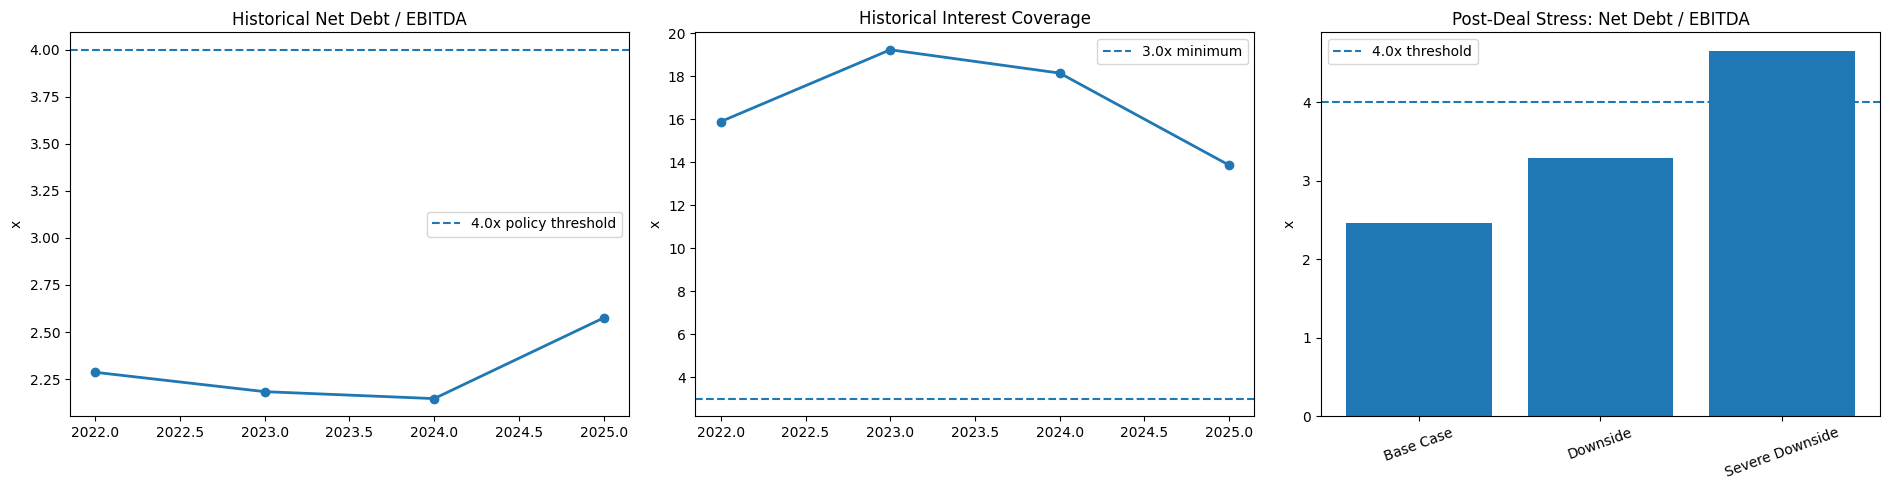

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Historical leverage
axes[0].plot(df_metrics.index.year, df_metrics["Net Debt / EBITDA"], marker="o", linewidth=2)
axes[0].axhline(MAX_NET_DEBT_EBITDA, linestyle="--", linewidth=1.5, label=f"{MAX_NET_DEBT_EBITDA:.1f}x policy threshold")
axes[0].set_title("Historical Net Debt / EBITDA")
axes[0].set_ylabel("x")
axes[0].legend()

# Historical coverage
axes[1].plot(df_metrics.index.year, df_metrics["Interest Coverage"], marker="o", linewidth=2)
axes[1].axhline(MIN_INTEREST_COVERAGE, linestyle="--", linewidth=1.5, label=f"{MIN_INTEREST_COVERAGE:.1f}x minimum")
axes[1].set_title("Historical Interest Coverage")
axes[1].set_ylabel("x")
axes[1].legend()

# Post-deal scenario leverage
axes[2].bar(post_deal_scenarios.index, post_deal_scenarios["Net Debt / EBITDA"])
axes[2].axhline(MAX_NET_DEBT_EBITDA, linestyle="--", linewidth=1.5, label=f"{MAX_NET_DEBT_EBITDA:.1f}x threshold")
axes[2].set_title("Post-Deal Stress: Net Debt / EBITDA")
axes[2].set_ylabel("x")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend()

plt.tight_layout()
plt.show()


## 11. Credit Committee Summary

In [ ]:
print("="*72)
print("ILLUSTRATIVE CREDIT COMMITTEE SUMMARY")
print("="*72)
print(f"Borrower: {market_info['long_name']} ({TICKER})")
print(f"Latest EBITDA: ${current_ebitda/1e9:,.2f}bn")
print(f"Latest Net Debt / EBITDA: {latest['Net Debt / EBITDA']:.2f}x")
print(f"Latest Interest Coverage: {latest['Interest Coverage']:.2f}x")
print(f"Illustrative Risk Score: {risk_score:.2f}/5")
print()
print(f"Hypothetical facility: ${PROPOSED_DEBT/1e9:,.2f}bn at {PROPOSED_RATE:.1%}")
print(f"Post-deal leverage: {post_deal_leverage:.2f}x")
print(f"Post-deal interest coverage: {post_deal_interest_coverage:.2f}x")
print(f"Theoretical incremental capacity at {MAX_NET_DEBT_EBITDA:.1f}x: ${incremental_capacity/1e9:,.2f}bn")
print()
print("STRESS TEST")
for scenario in post_deal_scenarios.index:
    lev = post_deal_scenarios.loc[scenario, "Net Debt / EBITDA"]
    cov = post_deal_scenarios.loc[scenario, "Interest Coverage"]
    print(f"{scenario:16s} | Leverage {lev:.2f}x | Coverage {cov:.2f}x")

print()
print("Key underwriting considerations:")
print("• Earnings and cash-flow resilience should be assessed alongside leverage.")
print("• Downside operating performance materially affects leverage and debt-service capacity.")
print("• The facility and covenant thresholds are hypothetical modelling assumptions.")
print("• This analysis is not a credit rating or investment recommendation.")


ILLUSTRATIVE CREDIT COMMITTEE SUMMARY
Borrower: PepsiCo, Inc. (PEP)
Latest EBITDA: $15.54bn
Latest Net Debt / EBITDA: 2.57x
Latest Interest Coverage: 13.87x
Illustrative Risk Score: 1.60/5

Hypothetical facility: $2.00bn at 8.0%
Post-deal leverage: 2.70x
Post-deal interest coverage: 12.13x
Theoretical incremental capacity at 4.0x: $22.15bn

STRESS TEST
Base Case        | Leverage 2.46x | Coverage 13.32x
Downside         | Leverage 3.29x | Coverage 8.81x
Severe Downside  | Leverage 4.66x | Coverage 5.58x

Key underwriting considerations:
• Earnings and cash-flow resilience should be assessed alongside leverage.
• Downside operating performance materially affects leverage and debt-service capacity.
• The facility and covenant thresholds are hypothetical modelling assumptions.
• This analysis is not a credit rating or investment recommendation.


## 12. Data, Methodology & Limitations

### Data
The notebook programmatically retrieves historical financial statements through `yfinance`. For professional use, reported figures should be reconciled to the company's annual/quarterly filings before relying on them.

### Methodology
The analysis focuses on:
- profitability and margins
- total debt and net debt
- Net Debt / EBITDA
- interest coverage
- free cash flow / debt
- hypothetical leverage and coverage thresholds
- forward stress testing
- theoretical debt capacity

### Limitations
- Scenario assumptions are illustrative.
- The risk score is an internal analytical score, not an external credit rating.
- The covenant thresholds are hypothetical and are not PepsiCo's contractual covenants.
- Debt capacity depends on lender-specific adjustments, documentation, collateral, liquidity, cash-flow quality, maturity profile and other factors not fully modelled here.
- Yahoo Finance data should be independently reconciled to primary filings for investment-grade analysis.


# Portfolio Project Takeaway

This model demonstrates a **finance-first private-credit workflow** rather than an opaque machine-learning prediction:

**financial statements → normalization → credit metrics → risk scoring → stress testing → debt capacity → covenant/headroom analysis → credit committee summary**

The important interview skill is being able to explain **why each metric matters and how each formula affects the lending decision**.
